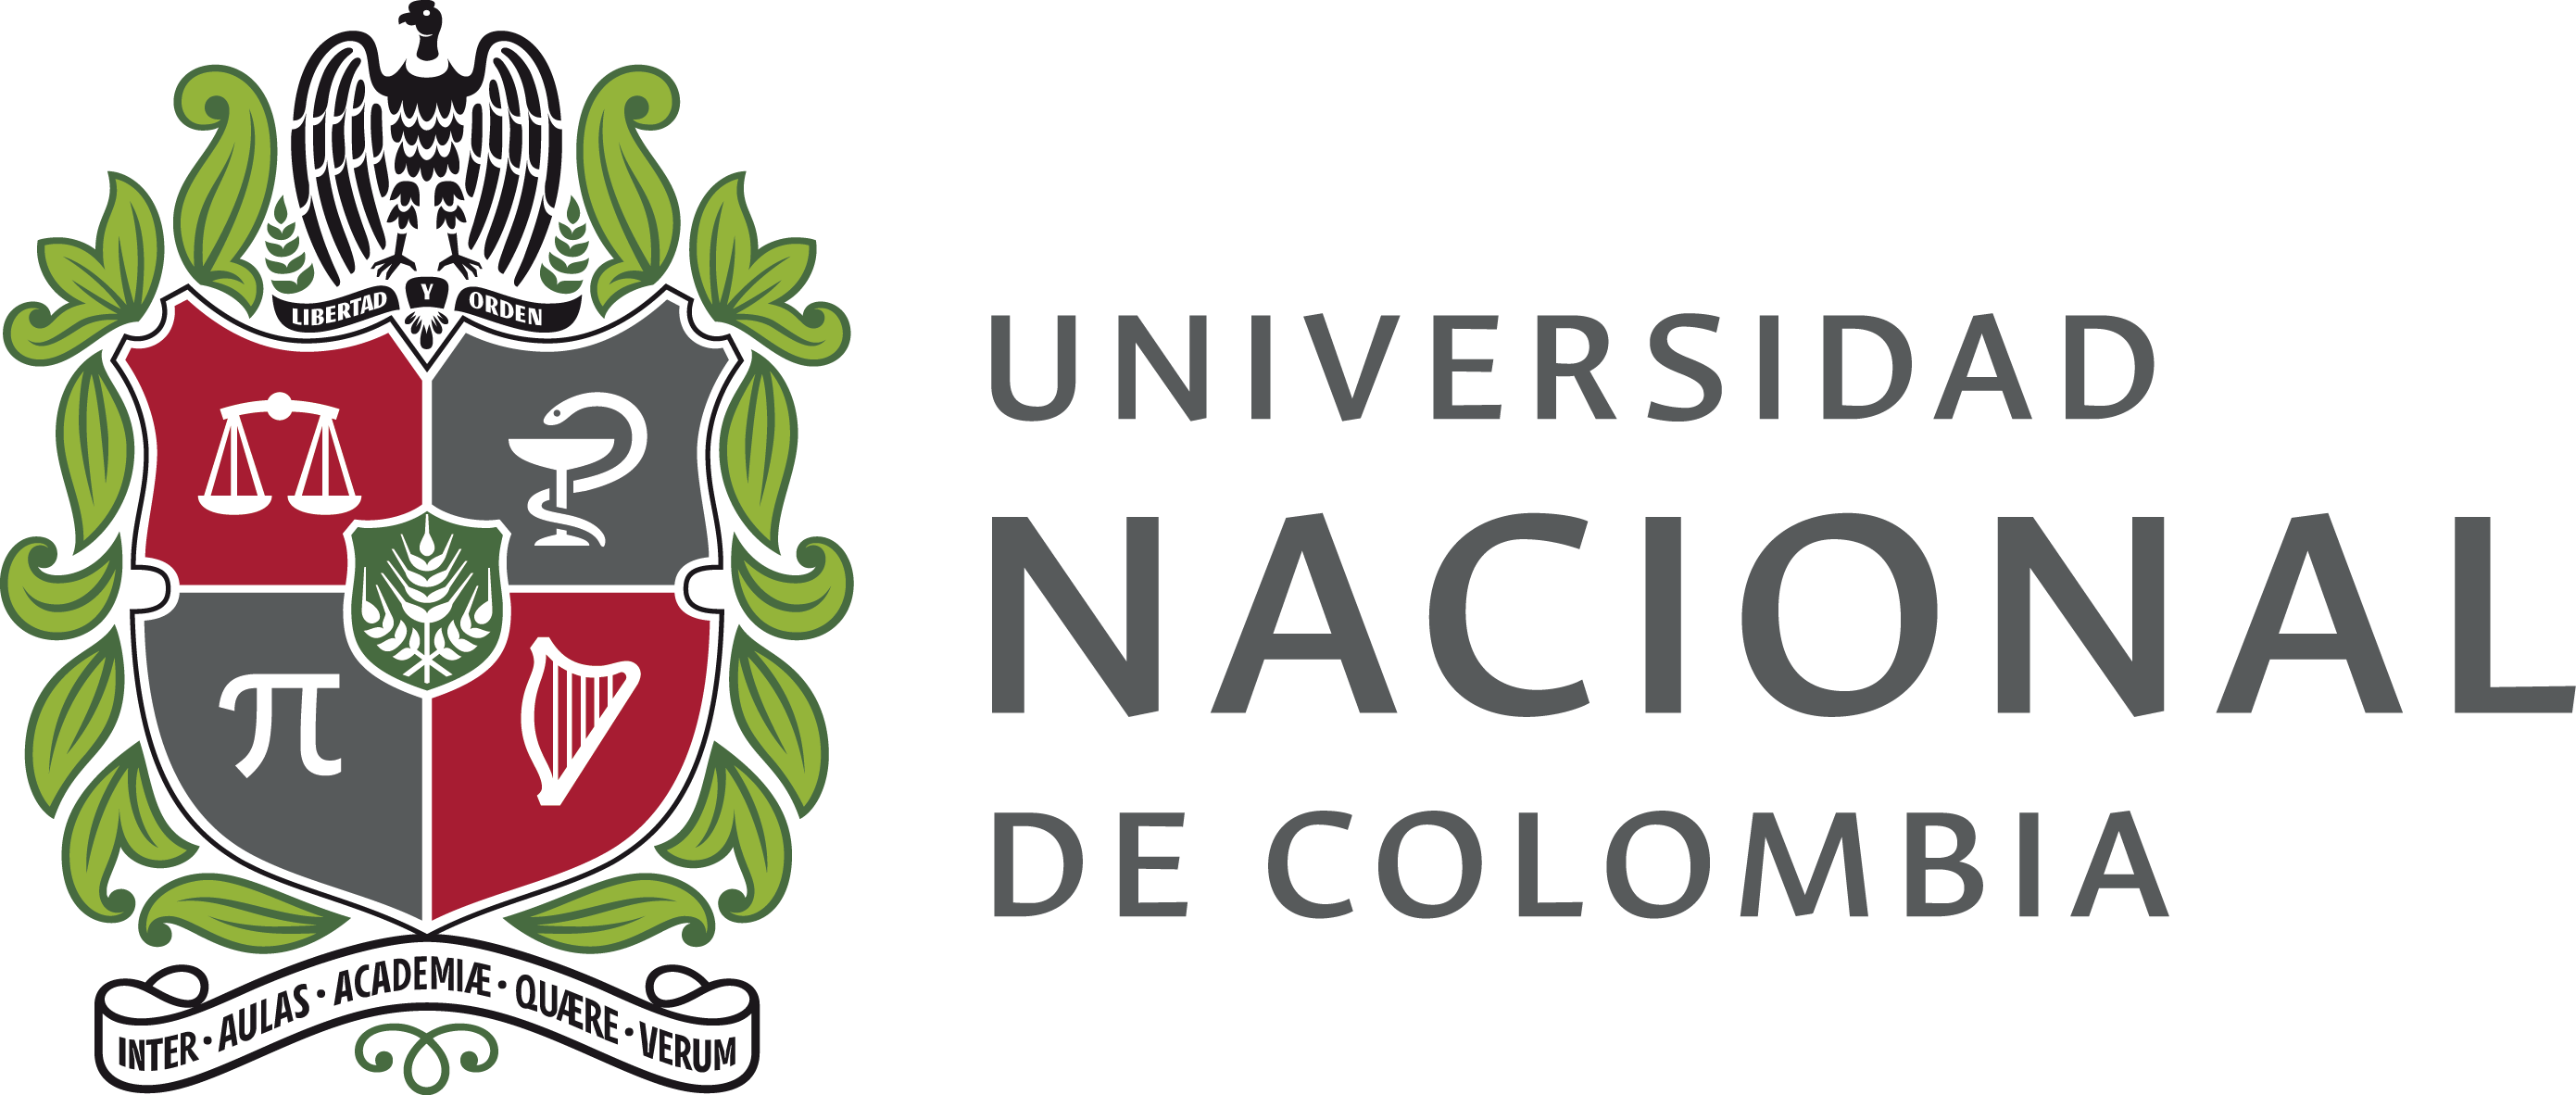
### **Universidad Nacional de Colombia sede Manizales**
#### Facultad de ingeniería y arquitectura
#### Departamento de ingeniería eléctrica, electrónica y computación
#### *Procesamiento digital de imágenes*

#### Profesor: Lucas Iturriago

## Redes convolucionales

### 11.1 Motivación

Una imagen típica de $256 \times 256$ píxeles en color tiene:
$$
256 \times 256 \times 3 = 196{,}608 \text{ entradas}
$$

Si conectamos esto a una capa totalmente conectada con solo 100 neuronas:
$$
196{,}608 \times 100 = 19{,}660{,}800 \text{ pesos}
$$

**Problemas:**

1. **Demasiados parámetros** → sobreajuste, memoria, tiempo de entrenamiento.
2. **Pérdida de estructura espacial:** la red no sabe que los píxeles cercanos están relacionados.
3. **No hay invarianza a traslaciones:** mover un objeto unos píxeles cambia toda la entrada.

#### Limitaciones de las redes densas

| Problema              | Ejemplo                                      | Consecuencia           |
| :-------------------- | :------------------------------------------- | :--------------------- |
| Alta dimensionalidad  | Imágenes grandes → millones de pesos         | Impracticable          |
| Pérdida de estructura | Un gato desplazado cambia todas las entradas | No generaliza          |
| Poca eficiencia       | Pesos independientes por píxel               | Mucho cómputo          |
| Falta de jerarquía    | No detecta bordes, texturas, formas          | Sin comprensión visual |

#### **Aprovechar las estructuras locales**

Las imágenes tienen **alta correlación espacial**:
los píxeles cercanos suelen tener relación semántica (borde, textura, objeto).

En lugar de mirar todos los píxeles a la vez, se observan **pequeñas regiones locales (receptive fields)** y se aprenden **filtros reutilizables** que se aplican en toda la imagen.

Propiedades fundamentales de las CNNs

| Propiedad                   | Descripción                                                   | Beneficio                                    |
| :-------------------------- | :------------------------------------------------------------ | :------------------------------------------- |
| **Localidad**               | Los filtros operan sobre vecindades pequeñas (ej. $3 \times 3$) | Capturan patrones locales (bordes, texturas) |
| **Compartición de pesos**   | El mismo filtro se aplica en toda la imagen                   | Reduce drásticamente los parámetros          |
| **Invarianza a traslación** | Un patrón detectado en una zona se reconoce en otra           | Generalización espacial                      |

#### Analogía visual

Una CNN funciona como un explorador que recorre una imagen con una lupa (el kernel), buscando patrones conocidos —bordes, esquinas, texturas— y combinándolos para formar conceptos más complejos como “ojo”, “cara”, o “auto”.

In [1]:
# @title
import os
import requests

# Carpeta de destino
dest_dir = "imagenes_pdi_clase6"
os.makedirs(dest_dir, exist_ok=True)

# Lista de archivos con su URL raw en GitHub
image_urls = {
    "gato.png": "https://raw.githubusercontent.com/UN-GCPDS/ProcesamientoDigitalImagenes/main/Clase%206/Figuras/gato.png",
}

def download_file(url, dest_path, chunk_size=8192, timeout=30):
    try:
        with requests.get(url, stream=True, timeout=timeout) as r:
            r.raise_for_status()
            with open(dest_path, "wb") as f:
                for chunk in r.iter_content(chunk_size=chunk_size):
                    if chunk:  # filtra keep-alive chunks
                        f.write(chunk)
        return True, None
    except Exception as e:
        return False, str(e)

results = {}
for fname, url in image_urls.items():
    out_path = os.path.join(dest_dir, fname)
    ok, err = download_file(url, out_path)
    results[fname] = "OK" if ok else f"ERROR: {err}"

In [2]:
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import transforms
import torchvision.models as models
from torchvision.datasets import OxfordIIITPet
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader, random_split
from torchvision.transforms.functional import to_pil_image
import random
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score

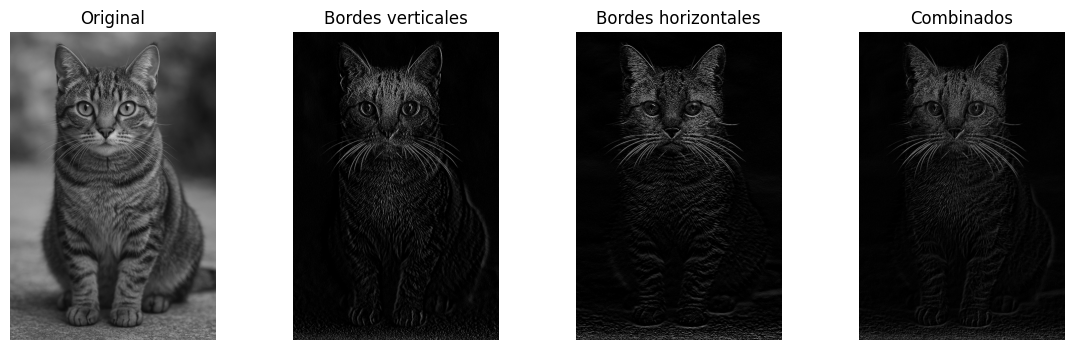

In [3]:
# Cargar imagen en escala de grises
img = cv2.imread('./imagenes_pdi_clase6/gato.png', cv2.IMREAD_GRAYSCALE)
img_rgb = cv2.cvtColor(cv2.imread('./imagenes_pdi_clase6/gato.png'),cv2.COLOR_BGR2RGB)

# Definir filtros (kernels)
sobel_x = np.array([[-1,0,1],
                    [-2,0,2],
                    [-1,0,1]], dtype=np.float32)

sobel_y = np.array([[-1,-2,-1],
                    [ 0, 0, 0],
                    [ 1, 2, 1]], dtype=np.float32)

# Aplicar convoluciones
edges_x = cv2.filter2D(img, -1, sobel_x)
edges_y = cv2.filter2D(img, -1, sobel_y)
edges = cv2.addWeighted(edges_x, 0.5, edges_y, 0.5, 0)

# Visualizar resultados
fig, axs = plt.subplots(1, 4, figsize=(14,4))
titles = ['Original', 'Bordes verticales', 'Bordes horizontales', 'Combinados']
images = [img, edges_x, edges_y, edges]

for ax, im, title in zip(axs, images, titles):
    ax.imshow(im, cmap='gray')
    ax.set_title(title)
    ax.axis('off')

plt.show()

### 11.2 Kernels: detectores de patrones

Los **filtros convolucionales** (o *kernels*) son matrices pequeñas de pesos que la red aprende.
Cada filtro actúa como un “detector especializado”: algunos responden a **bordes horizontales**, otros a **texturas**, otros a **formas complejas**.

#### Tipos de filtros según frecuencia

| Tipo                | Descripción                                                            | Ejemplo visual                   |
| ------------------- | ---------------------------------------------------------------------- | -------------------------------- |
| **Baja frecuencia** | Capturan cambios suaves, regiones amplias, colores o sombras globales. | Fondo, contornos suaves.         |
| **Alta frecuencia** | Capturan detalles abruptos, bordes, ruido o texturas finas.            | Líneas, esquinas, pelos, letras. |

Las primeras capas suelen aprender **filtros de alta frecuencia** (bordes, texturas).
Las capas intermedias y finales aprenden **patrones de baja frecuencia combinada**, que representan *partes de objetos o conceptos completos*.

#### Mapas de activación (Feature Maps)

**Ejemplo de implementación en PyTorch:**

Visualización de los filtros y mapas de activación de una CNN entrenada (por ejemplo, una `Conv2d` inicial de una red sobre CIFAR-10):

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 195MB/s]


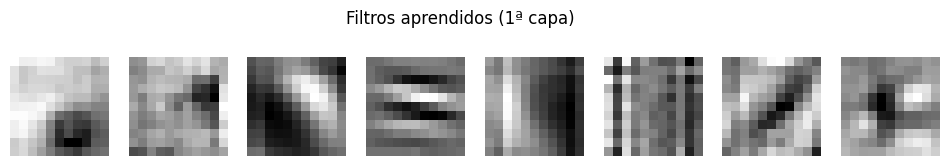

In [4]:
# Una red preentrenada
model = models.alexnet(pretrained=True)
first_conv = model.features[0]

# Los primeros 8 filtros (kernels)
with torch.no_grad():
    weights = first_conv.weight.cpu()
    fig, axes = plt.subplots(1, 8, figsize=(12, 2))
    for i in range(8):
        axes[i].imshow(weights[i][0], cmap='gray')
        axes[i].axis('off')
plt.suptitle("Filtros aprendidos (1ª capa)")
plt.show()

Y para los **mapas de activación** de una imagen de entrada:

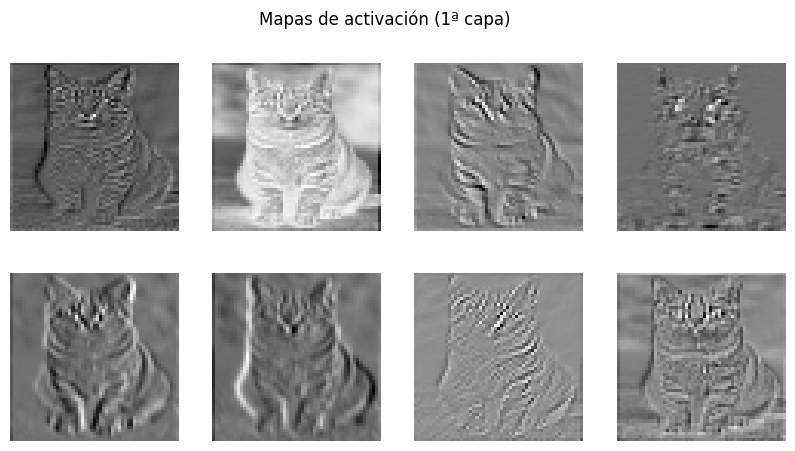

In [6]:
# Preprocesamiento
preprocess = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])
img = preprocess(Image.open("./imagenes_pdi_clase6/gato.png")).unsqueeze(0)

# Primera capa
with torch.no_grad():
    activation = first_conv(img)

# Visualización de algunos mapas
fig, axes = plt.subplots(2, 4, figsize=(10,5))
for i, ax in enumerate(axes.flat):
    ax.imshow(activation[0, i].cpu(), cmap='gray')
    ax.axis('off')
plt.suptitle("Mapas de activación (1ª capa)")
plt.show()

### 11.3 Estructura de una red convolucional

Una CNN típica está compuesta por varias capas organizadas en un **pipeline jerárquico**:

```
Entrada → Convolución → Activación → Pooling → (Repetir varias veces)
         → Flatten → Capas totalmente conectadas → Salida
```

#### Capa de Convolución

**Propósito:**
Extraer patrones locales de la imagen mediante filtros (kernels) aprendibles.

**Operación:**
Cada filtro de tamaño $k \times k$ se desliza sobre la imagen y calcula:

$$
y(i,j) = \sum_{m,n} w_{m,n} \cdot x_{i+m, j+n}
$$

**Hiperparámetros clave:**

| Parámetro     | Significado                       | Efecto                                 |
| :------------ | :-------------------------------- | :------------------------------------- |
| `kernel_size` | Tamaño del filtro (e.g. 3×3, 5×5) | Define el área de visión local         |
| `stride`      | Paso del filtro                   | Controla reducción de tamaño           |
| `padding`     | Borde añadido a la entrada        | Evita pérdida de bordes                |
| `channels`    | # de mapas de características     | Más filtros = más diversidad de rasgos |

**Ejemplo de implementación en PyTorch:**

```python
nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, stride=1, padding=1)
```

Resultado: 32 mapas de activación, cada uno sensible a un patrón distinto.

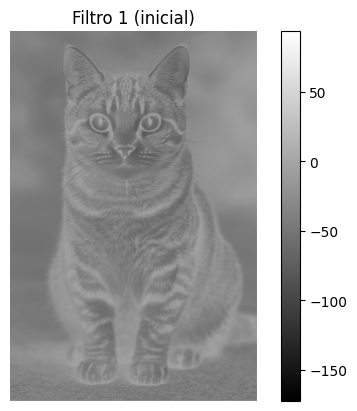

In [7]:
# HWC -> BCHW (1,3,H,W)
img = torch.from_numpy(img_rgb.transpose(2, 0, 1)).float().unsqueeze(0)
# Conv capa
conv = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, stride=1, padding=1)
# (1,32,H,W)
convd_img = conv(img)

# muestra el mapa del 23º filtro
plt.imshow(convd_img[0,1].detach().numpy(), cmap='gray')
plt.title('Filtro 1 (inicial)')
plt.colorbar(); plt.axis('off'); plt.show()

#### Función de Activación

**Propósito:**
Introducir **no linealidad** para permitir que la red aprenda relaciones complejas.

**Funciones comunes:**

| Activación         | Fórmula                      | Comentario                            |
| :----------------- | :--------------------------- | :------------------------------------ |
| **ReLU**           | $f(x) = \max(0, x)$          | Rápida y evita gradiente saturado     |
| **Leaky ReLU**     | $f(x) = \max(\alpha x, x)$   | Evita “muerte” de neuronas            |
| **Sigmoid**        | $f(x) = \frac{1}{1+e^{-x}}$        | Usadas en salidas para clasificación binaria |
| **Tanh**           | $f(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$        | Usadas en salidas o casos específicos |

**Ejemplo de implementación en PyTorch:**

nn.ReLU(inplace=True)

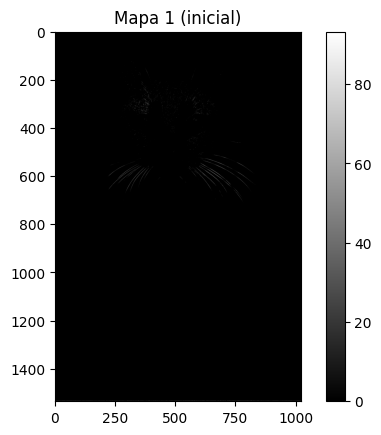

In [8]:
# ReLU op
relu = nn.ReLU(inplace=True)
# (1,32,H,W)
relud_img = relu(convd_img)

# muestra el mapa del 1º filtro con ReLU
plt.imshow(relud_img[0,1].detach().numpy(), cmap='gray')
plt.title('Mapa 1 (inicial)')
plt.colorbar(); plt.show()

#### Capa de Pooling

**Propósito:**
Reducir la dimensionalidad y hacer la representación más **invariante a pequeñas traslaciones**.

**Tipos:**

| Tipo                | Operación            | Uso                        |
| :------------------ | :------------------- | :------------------------- |
| **Max Pooling**     | Toma el valor máximo | Destaca rasgos más fuertes |
| **Average Pooling** | Promedia los valores | Preserva suavidad          |

**Ejemplo:**

* `nn.MaxPool2d(kernel_size=2, stride=2)` → reduce la resolución a la mitad.

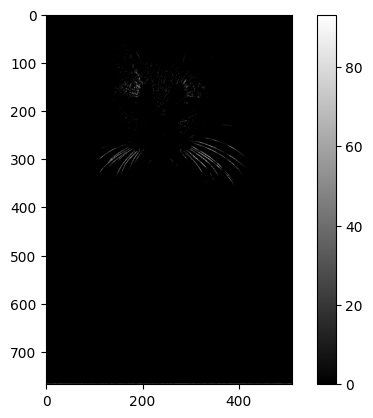

In [9]:
# Pooling op
pool = nn.MaxPool2d(kernel_size=2, stride=2)
# (1,32,H,W)
pooled_img = pool(relud_img)

# muestra el mapa del 1º filtro con ReLU+Pooling
plt.imshow(pooled_img[0,1].detach().numpy(), cmap='gray')
plt.colorbar(); plt.show()

#### Normalización

**Propósito:**
Acelerar el aprendizaje y estabilizar el entrenamiento.

* **Batch Normalization:** normaliza activaciones por lote.
  [
  \hat{x} = \frac{x - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}}
  ]
* Reduce el “internal covariate shift”.

**Ejemplo de implementación en PyTorch:**

```python
nn.BatchNorm2d(num_features=32)
```

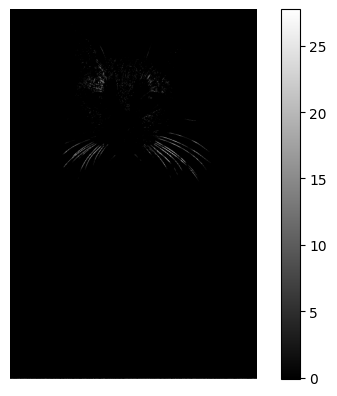

In [10]:
# BatchNorm op
batch_norm = nn.BatchNorm2d(num_features=32)
# (1,32,H,W)
norm_img = batch_norm(pooled_img)

# muestra el mapa del 1º filtro con ReLU+Pooling+BatchNorm
plt.imshow(norm_img[0,1].detach().numpy(), cmap='gray')
plt.colorbar(); plt.axis('off'); plt.show()

#### Capas completamente conectadas (Fully Connected)

**Propósito:**
Combinar las características aprendidas por las capas convolucionales y producir la decisión final.

**Proceso:**

1. Se aplana la salida del bloque convolucional (`Flatten`).
2. Se conectan todas las neuronas a una capa densa final con activación *softmax* o *sigmoid* (según el tipo de tarea).

**Ejemplo de implementación en PyTorch:**

```python
nn.Linear(512, num_classes)
```

In [11]:
# Flatten op
flatten = nn.Flatten()

flat_img = flatten(norm_img)

# Dense capa
#linear = nn.Linear(flat_img)

**Ejemplo de implementación en PyTorch de una arquitectura CNN simple**

In [12]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d((8, 8))   # ← fuerza 8×8
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*8*8, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [13]:
model = SimpleCNN()
prediction = model(img)
prediction.shape

torch.Size([1, 10])

## Clasificación de imágenes

### 12.1 Concepto central

La **clasificación de imágenes** consiste en tomar una **imagen completa** como entrada y asignarle una **etiqueta única** de entre un conjunto finito de clases posibles.

$$
f_\theta : \mathbb{R}^{H \times W \times C} \rightarrow {1, 2, ..., N}
$$

donde:

* $H, W, C$: alto, ancho y canales de la imagen,
* $N$: número de clases posibles,
* $f_{\theta}$: red convolucional parametrizada por pesos $\theta$.

El modelo produce un vector de probabilidades $\hat{y}$:

$$
\hat{y} = [0.02, 0.01, 0.92, 0.03, 0.02]
$$

Interpretación:

* 92% probabilidad de “perro”,
* 3% de “gato”,
* 2% de “auto”…

La clase con mayor probabilidad es la **predicción final**:

$$
\text{Clase predicha} = \arg\max_i \hat{y}_i
$$

#### Flujo general de una CNN para clasificación de imágenes

1. **Extracción de características:**
   Las capas convolucionales identifican patrones locales (bordes, texturas, partes).
2. **Agrupamiento progresivo:**
   Capas más profundas combinan esas características en conceptos (rostros, ruedas, hojas).
3. **Aplanamiento y decisión final:**
   Las capas totalmente conectadas (*fully connected*) reciben el resumen de todo lo visto.
4. **Softmax final:**
   Convierte las salidas numéricas en una distribución de probabilidad sobre las clases.

$$
\hat{y}_i = \frac{e^{z_i}}{\sum_j e^{z_j}}
$$

donde $\hat{y}_i$ indica la **probabilidad** de que la imagen pertenezca a la clase $i$.

### 12.2 Arquitecturas representativas para clasificación de imágenes

#### LeNet-5 (1998) — Los cimientos de la visión artificial

A finales de los años 90, **Yann LeCun** y su equipo en AT&T Bell Labs presentaron **LeNet-5**, una red diseñada para **reconocer dígitos escritos a mano** (el dataset MNIST).
Fue el **primer modelo CNN funcional** entrenado de extremo a extremo con *backpropagation*.

##### Estructura general

![LeNet Architecture](https://www.researchgate.net/profile/Ghanapriya-Singh/publication/351589447/figure/fig3/AS:1024145965977600@1621186834158/Structure-of-the-LeNet-5-model-architecture.png)

$$
\text{Input} \rightarrow \text{Conv} \rightarrow \text{Pool} \rightarrow
\text{Conv} \rightarrow \text{Pool} \rightarrow \text{FC} \rightarrow \text{Output}
$$

* **Entrada:** $32 \times 32$ píxeles.
* **2 capas convolucionales** con *tanh* como activación.
* **2 capas de pooling** (subsampling).
* **2 capas completamente conectadas**.
* **Salida:** 10 neuronas (para los dígitos 0–9).

##### Innovaciones clave

* Introducción del concepto de **receptive field local**.
* Uso de **pesos compartidos** (convolución).
* Capas de **submuestreo** para reducir dimensionalidad.
* Entrenamiento *end-to-end* supervisado.

#### AlexNet (2012) — El renacimiento del Deep Learning

Después de más de una década de estancamiento por limitaciones computacionales, **Alex Krizhevsky, Ilya Sutskever y Geoffrey Hinton** revolucionaron el campo con **AlexNet**, ganador del **ImageNet Challenge 2012**.
Reducir el error *Top-5* del 26% al 15% fue un salto histórico.

##### Estructura general

![AlexNet arquitectura](https://www.researchgate.net/publication/358898505/figure/fig5/AS:1128295315841025@1646017974388/AlexNet-like-architecture-One-of-the-3-self-constructed-CNN-architectures-used-in-our.ppm)

$$
\text{Input (227×227×3)} → [\text{Conv–ReLU–Pool}]×5 → FC → Softmax
$$

* **8 capas aprendibles**: 5 convolucionales + 3 completamente conectadas.
* **ReLU** como función de activación → aceleró el entrenamiento.
* **Dropout** → redujo el sobreajuste.


##### Innovaciones técnicas

| Innovación                  | Impacto                                      |
| --------------------------- | -------------------------------------------- |
| **ReLU** $f(x)=\max(0,x)$ | Acelera convergencia, evita saturación.      |
| **Dropout**                 | Previene sobreajuste masivo.                 |
| **GPU Training**            | Permite redes profundas en tiempo razonable. |
| **Data Augmentation**       | Mejora la generalización.                    |

#### VGG (2014) — La elegancia de la simplicidad

Creada por **Karen Simonyan y Andrew Zisserman** (Oxford), **VGG** propuso una idea simple pero poderosa:

> “Profundidad mediante bloques repetitivos de convoluciones pequeñas.”

En lugar de usar filtros grandes (como 7×7 o 11×11), VGG demostró que **apilar múltiples filtros 3×3** logra un campo receptivo mayor con menos parámetros y mejor aprendizaje.

##### Estructura general

![VGG-16 arquitectura](https://neurohive.io/wp-content/uploads/2018/11/vgg16-1-e1542731207177.png)

Ejemplo de **VGG-16**:
$$
(\text{Conv3–Conv3–Pool}) \times 2 +
(\text{Conv3–Conv3–Conv3–Pool}) \times 3 +
FC + FC + Softmax
$$

* 13 capas convolucionales.
* 3 capas completamente conectadas.
* Total ≈ 138 millones de parámetros.

##### Innovaciones técnicas

| Elemento                    | Idea                                        |
| --------------------------- | ------------------------------------------- |
| **Filtros 3×3**             | Mayor profundidad con simplicidad.          |
| **Bloques homogéneos**      | Arquitectura modular, fácil de extender.    |
| **Uniformidad estructural** | Simplifica la implementación y el análisis. |

#### ResNet (2015) — El salto a la ultra-profundidad

Desarrollada por **Kaiming He et al. (Microsoft Research)**, **ResNet** introdujo un cambio conceptual radical:

> *Aprender la diferencia (residuo) entre la entrada y la salida, en lugar de aprender la transformación completa.*

Con esto resolvió el problema del **gradiente que se desvanece** al entrenar redes muy profundas.

$$
y = F(x) + x
$$
donde $F(x)$ es la transformación aprendida (bloque convolucional) y $x$ es la entrada original.

Así, si $F(x)$ aprende una función identidad $F(x)=0$, el bloque simplemente pasa la información sin modificarla.
Esto facilita el flujo del gradiente durante el *backpropagation*.

##### Estructura general

![ResNet34 arquitectura](https://th.bing.com/th/id/R.51afa5b154362d0bf37a65edf80c6a1d?rik=3KNb7%2bXRZxiqug&pid=ImgRaw&r=0)

* Bloque **Residual básico**: Conv → BN → ReLU → Conv → BN → + skip connection → ReLU
* Versiones: ResNet18, 34, 50, 101, 152 (el número indica profundidad).
* Uso de **Batch Normalization**, **Global Average Pooling** y **He initialization**.

##### Innovaciones técnicas

| Elemento                 | Impacto                                         |
| ------------------------ | ----------------------------------------------- |
| **Skip connections**     | Facilitan entrenamiento de redes >100 capas.    |
| **Identidad residual**   | Flujo de información sin pérdida.               |
| **Batch Normalization**  | Estabiliza y acelera entrenamiento.             |
| **Arquitectura modular** | Base para ResNeXt, DenseNet, EfficientNet, etc. |

#### Resumen general

| Arquitectura | Año  | Capas  | Innovación clave           | Limitaciones            | Legado                    |
| ------------ | ---- | ------ | -------------------------- | ----------------------- | ------------------------- |
| **LeNet-5**  | 1998 | 7      | Convolución + Pooling + FC | Capacidad limitada      | Base conceptual           |
| **AlexNet**  | 2012 | 8      | ReLU, Dropout, GPU         | Pesada, sobreajuste     | Renacimiento del DL       |
| **VGG**      | 2014 | 16–19  | Bloques 3×3 repetitivos    | Muchísimos parámetros   | Estandarización modular   |
| **ResNet**   | 2015 | 18–152 | Skip connections           | Complejidad estructural | Arquitectura moderna base |

### 12.3 Funciones de pérdida para clasificación de imágenes

En clasificación, el modelo predice una **distribución de probabilidades** $\hat{y}$ sobre las posibles clases.
La **función de pérdida (loss)** mide *qué tan lejos* está esa distribución de la verdadera etiqueta (y).

El entrenamiento busca **minimizar esa diferencia** ajustando los pesos de la red:

$$
\theta^* = \arg\min_\theta \mathcal{L}(y, \hat{y}_\theta)
$$

#### Cross-Entropy Loss

**Definición**

$$
\mathcal{L}*{CE} = -\sum_{i=1}^{N} y_i \log(\hat{y}_i)
$$

Donde:

* $y_i$ es 1 para la clase correcta y 0 para las demás.
* $\hat{y}_i$ es la probabilidad predicha para la clase $i$ (salida del *Softmax*).

**Consideraciones**

* Matemáticamente sólida (deriva del concepto de *entropía de información*).
* Bien comportada y estable numéricamente.
* Permite interpretación probabilística directa.
* Supone **una sola clase verdadera** (no multi-label).
* Sensible a **clases desbalanceadas** → puede sesgarse hacia las mayoritarias.
* Penaliza fuertemente predicciones seguras pero incorrectas (útil, pero a veces excesivo).

#### Weighted Cross-Entropy

**Definición**

Se introduce un **peso por clase** $w_i$:

$$
\mathcal{L}*{WCE} = -\sum_{i=1}^{N} w_i y_i \log(\hat{y}_i)
$$

Donde:
$w_i \propto 1/f_i$ (inversamente proporcional a la frecuencia de la clase).

#### Focal Loss

**Definición**


Propuesta por Lin et al. (RetinaNet, 2017).
Reduce el peso de ejemplos “fáciles” y enfatiza los “difíciles”.

$$
\mathcal{L}*{FL} = -\sum_{i=1}^{N} (1 - \hat{y}_i)^\gamma y_i \log(\hat{y}_i)
$$

Donde:

* $\gamma$ es un parámetro de enfoque (típicamente entre 1 y 5).
* Si una predicción es muy segura (alta $\hat{y}_i$), su contribución a la pérdida disminuye.

**Consideraciones**

* Excelente para **datasets desbalanceados**.
* Mejora la sensibilidad a clases minoritarias o difíciles.
* Añade un hiperparámetro ((\gamma)) que requiere ajuste.
* Puede ralentizar el aprendizaje si se exagera el enfoque.

#### Label Smoothing

**Definición**

Evita que el modelo se vuelva **demasiado confiado** en una sola clase.

En vez de una etiqueta “dura”:
$$
y = [0,0,1,0] \Rightarrow y' = [0.02, 0.02, 0.94, 0.02]
$$

Nueva pérdida:

$$
\mathcal{L}_{LS} = -\sum_i y'_i \log(\hat{y}_i)
$$

**Consideraciones**

* Reduce el **overfitting**.
* Mejora la **calibración de probabilidades**.
* Puede dificultar alcanzar una confianza del 100% incluso cuando la predicción es correcta.

#### Resumen general

| Pérdida             | Ideal para               | Pros                                  | Contras                |
| ------------------- | ------------------------ | ------------------------------------- | ---------------------- |
| **Cross-Entropy**   | Clasificación estándar   | Estable, interpretativa               | Desbalance             |
| **Weighted CE**     | Clases desbalanceadas    | Simple de implementar                 | Puede sobreponderar    |
| **Focal Loss**      | Desbalance extremo       | Focaliza ejemplos difíciles           | Requiere ajustar γ     |
| **Label Smoothing** | Overconfidence           | Mejor calibración                     | Menor exactitud máxima |

### 12.4 Medidas de rendimientos (metrics)

La *función de pérdida* mide el error promedio del modelo durante el aprendizaje.
Sin embargo, no siempre refleja la **calidad de las decisiones finales**.

Por ejemplo:

* Un modelo puede tener **baja pérdida** pero equivocarse sistemáticamente en una clase minoritaria.
* O puede tener **alta precisión general**, pero fallar en los casos críticos (como detección de enfermedades).

Las métricas complementan la visión del rendimiento.

#### Matriz de confusión (Confusion Matrix)

Es el **núcleo visual** de la evaluación en clasificación.

Cada celda indica cuántas muestras de una clase **verdadera** fueron clasificadas en cada clase **predicha**.

![Matrix de confusión](https://miro.medium.com/v2/resize:fit:1400/1*ZSJ_vYSZyeQTau5G68tN6g.png)

**Diagonal principal** → aciertos.
**Fuera de la diagonal** → errores.

#### Accuracy

La métrica más simple y popular.

$$
\text{Accuracy} = \frac{\text{N° de aciertos}}{\text{N° total de muestras}} = \frac{TP + TN}{TP + TN + FP + FN}
$$

**Consideraciones**

* Engañosa si hay **clases desbalanceadas**.
  Ejemplo: si 95% son perros, un modelo que siempre diga “perro” tiene 95% accuracy, pero **no sirve**.

#### Precision

$$
\text{Precision} = \frac{TP}{TP + FP}
$$

Mide **cuán confiables son las predicciones positivas** del modelo.

**Consideraciones**

* Alta precisión → pocos falsos positivos.
* Ejemplo: modelo conservador, solo dice clase "gato" si está muy seguro.

#### Recall

$$
\text{Recall} = \frac{TP}{TP + FN}
$$

Mide **qué tanto logra encontrar la clase verdadera**.

**Consideraciones**

* Alto recall → pocos falsos negativos.
* Ejemplo: modelo que prefiere “no dejar pasar ningún gato”, aunque se equivoque con algunos perros.

#### F1-Score

$$
F1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}
$$

Balancea precisión y recall en **una sola métrica**.

**Consideraciones**
* Ideal cuando el dataset es **desbalanceado**.
* Penaliza los extremos: si una de las dos es baja, el F1 también lo será.

#### Top-k Accuracy

$$
\text{Top-}k = \frac{\text{N° de veces que la clase verdadera está entre las } k \text{ más probables}}{\text{Total de muestras}}
$$

Ejemplo:

* **Top-1:** clase correcta = predicción más probable.
* **Top-5:** clase correcta está entre las 5 con mayor probabilidad.

Ideal cuando las clases son muy similares y hay varias

### 12.5 Entrenamiento y uso de la transferencia de aprendizaje

Entrenar desde cero una red profunda como ResNet18 requeriría **millones de imágenes y gran capacidad de cómputo**.
El *transfer learning* permite **reutilizar el conocimiento** de un modelo entrenado en un gran dataset (p. ej., ImageNet) para una tarea nueva más pequeña.

**Estrategia general**

1. **Congelar capas iniciales** (aprenden patrones genéricos: bordes, texturas, colores).
2. **Reentrenar las capas finales** (aprenden patrones específicos de la nueva tarea).

**Beneficios**

* Requiere menos datos.
* Entrenamiento más rápido.
* Mejora la generalización.

### Implementación práctica en PyTorch)

In [14]:
# 1. Configuración general

seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [15]:
# 2. Transformaciones (preprocesamiento de imágenes)
train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [16]:
# 3. Carga del Dataset: Oxford-IIIT Pet

root = "./data"

# Cargar sin transformaciones primero
trainval_base = OxfordIIITPet(
    root=root,
    split="trainval",
    target_types="category",
    download=True
)

test_base = OxfordIIITPet(
    root=root,
    split="test",
    target_types="category",

    download=True
)

# División train/val a partir del conjunto "trainval"
n_total = len(trainval_base)
n_val = int(0.2 * n_total)
n_train = n_total - n_val

class WrappedPet(torch.utils.data.Dataset):
    """Aplica una transformación a un dataset base."""
    def __init__(self, base_dataset, transform=None):
        self.base = base_dataset
        self.transform = transform
    def __len__(self):
        return len(self.base)
    def __getitem__(self, idx):
        img, target = self.base[idx]
        if self.transform:
            img = self.transform(img)
        return img, target

trainval_wrapped = WrappedPet(trainval_base, transform=train_transform)
train_ds, val_ds = random_split(trainval_wrapped, [n_train, n_val])

# Aplicar transformación de validación al val_ds
class ValidationDataset(torch.utils.data.Dataset):
    """Dataset de validación con transformación específica."""
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        img, target = self.subset.dataset.base[self.subset.indices[idx]]
        if self.transform:
            img = self.transform(img)
        return img, target

val_ds = ValidationDataset(val_ds, test_transform)
test_ds = WrappedPet(test_base, transform=test_transform)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

100%|██████████| 792M/792M [00:29<00:00, 26.9MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 11.6MB/s]


Train: 2944 | Val: 736 | Test: 3669


In [17]:
# 4. Carga la data

batch_size = 32
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [18]:
# 5. Modelo: ResNet18 preentrenada (transfer learning)

model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Congelamos todas las capas convolucionales
for param in model.parameters():
    param.requires_grad = False

# Sustituimos la capa final (fully connected)
num_features = model.fc.in_features
num_classes = 37  # Oxford-IIIT Pet tiene 37 categorías
model.fc = nn.Linear(num_features, num_classes)

model = model.to(device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 126MB/s]


In [19]:
# @title
def evaluate(model, loader, criterion):
    """Evalúa el modelo y retorna métricas."""
    model.eval()
    y_true, y_pred, losses = [], [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            losses.append(loss.item())
            preds = outputs.argmax(dim=1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    accuracy = accuracy_score(y_true, y_pred)
    avg_loss = np.mean(losses)

    return y_true, y_pred, avg_loss, accuracy


def train_epoch(model, loader, criterion, optimizer):
    """Entrena el modelo por una época y retorna métricas."""
    model.train()
    y_true, y_pred, losses = [], [], []

    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
        preds = outputs.argmax(dim=1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    accuracy = accuracy_score(y_true, y_pred)
    avg_loss = np.mean(losses)

    return avg_loss, accuracy


def plot_training_history(history):
    """Grafica loss y accuracy vs epoch."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Loss
    ax1.plot(history['train_loss'], label='Train Loss', marker='o')
    ax1.plot(history['val_loss'], label='Val Loss', marker='s')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('Loss vs Epoch')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Accuracy
    ax2.plot(history['train_acc'], label='Train Accuracy', marker='o')
    ax2.plot(history['val_acc'], label='Val Accuracy', marker='s')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.set_title('Accuracy vs Epoch')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(y_true, y_pred, title="Matriz de Confusión"):
    """Grafica la matriz de confusión."""
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    fig, ax = plt.subplots(figsize=(12, 10))
    disp.plot(ax=ax, xticks_rotation="vertical", cmap="Blues")
    plt.title(title)
    plt.tight_layout()
    plt.show()


def plot_classification_examples(model, loader, n_correct=8, n_incorrect=8):
    """Visualiza ejemplos correctos e incorrectos."""
    model.eval()
    correct_imgs, correct_preds, correct_labels = [], [], []
    wrong_imgs, wrong_preds, wrong_labels = [], [], []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            preds = model(imgs).argmax(dim=1)

            # Correctos
            correct_mask = preds == labels
            if correct_mask.any():
                correct_imgs.append(imgs[correct_mask].cpu())
                correct_preds.append(preds[correct_mask].cpu())
                correct_labels.append(labels[correct_mask].cpu())

            # Incorrectos
            wrong_mask = preds != labels
            if wrong_mask.any():
                wrong_imgs.append(imgs[wrong_mask].cpu())
                wrong_preds.append(preds[wrong_mask].cpu())
                wrong_labels.append(labels[wrong_mask].cpu())

            # Detener si ya tenemos suficientes ejemplos
            if len(torch.cat(correct_imgs)) >= n_correct and len(torch.cat(wrong_imgs)) >= n_incorrect:
                break

    # Concatenar todos los ejemplos
    if correct_imgs:
        correct_imgs = torch.cat(correct_imgs)[:n_correct]
        correct_preds = torch.cat(correct_preds)[:n_correct]
        correct_labels = torch.cat(correct_labels)[:n_correct]

    if wrong_imgs:
        wrong_imgs = torch.cat(wrong_imgs)[:n_incorrect]
        wrong_preds = torch.cat(wrong_preds)[:n_incorrect]
        wrong_labels = torch.cat(wrong_labels)[:n_incorrect]

    # Función auxiliar para desnormalizar imágenes
    def denormalize(img):
        img = img.permute(1, 2, 0).numpy()
        img = np.clip(img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406]), 0, 1)
        return img

    # Graficar correctos
    if len(correct_imgs) > 0:
        fig, axes = plt.subplots(1, min(n_correct, len(correct_imgs)), figsize=(3*n_correct, 3))
        if n_correct == 1:
            axes = [axes]
        fig.suptitle("Clasificaciones CORRECTAS", fontsize=16, fontweight='bold', color='green')
        for i in range(min(n_correct, len(correct_imgs))):
            img = denormalize(correct_imgs[i])
            axes[i].imshow(img)
            axes[i].set_title(f"Real: {correct_labels[i].item()}\nPred: {correct_preds[i].item()}",
                            color='green', fontweight='bold')
            axes[i].axis('off')
        plt.tight_layout()
        plt.show()
    else:
        print("No se encontraron clasificaciones correctas.")

    # Graficar incorrectos
    if len(wrong_imgs) > 0:
        fig, axes = plt.subplots(1, min(n_incorrect, len(wrong_imgs)), figsize=(3*n_incorrect, 3))
        if n_incorrect == 1:
            axes = [axes]
        fig.suptitle("Clasificaciones INCORRECTAS", fontsize=16, fontweight='bold', color='red')
        for i in range(min(n_incorrect, len(wrong_imgs))):
            img = denormalize(wrong_imgs[i])
            axes[i].imshow(img)
            axes[i].set_title(f"Real: {wrong_labels[i].item()}\nPred: {wrong_preds[i].item()}",
                            color='red', fontweight='bold')
            axes[i].axis('off')
        plt.tight_layout()
        plt.show()
    else:
        print("No se encontraron errores de clasificación.")

In [20]:
# 6. Entrenamiento

n_epochs = 6
best_val_acc = 0.0
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=1e-3)

# Historial de entrenamiento
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

print("\n" + "="*60)
print("INICIANDO ENTRENAMIENTO")
print("="*60)

for epoch in range(n_epochs):
    # Entrenar
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)

    # Validar
    y_true, y_pred, val_loss, val_acc = evaluate(model, val_loader, criterion)

    # Guardar historial
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"Epoch {epoch+1:02d}/{n_epochs} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    # Guardar mejor modelo
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_resnet18_oxford_pet.pth")
        print("  → Modelo mejorado guardado ✓")

print("="*60)
print("ENTRENAMIENTO COMPLETADO")
print("="*60 + "\n")


INICIANDO ENTRENAMIENTO


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Epoch 01/6 | Train Loss: 2.4125 | Train Acc: 0.4283 | Val Loss: 1.2490 | Val Acc: 0.7446
  → Modelo mejorado guardado ✓


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Epoch 02/6 | Train Loss: 1.2608 | Train Acc: 0.7218 | Val Loss: 0.7805 | Val Acc: 0.8179
  → Modelo mejorado guardado ✓


...

Epoch 04/6 | Train Loss: 0.8203 | Train Acc: 0.7935 | Val Loss: 0.5383 | Val Acc: 0.8560
  → Modelo mejorado guardado ✓


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Epoch 05/6 | Train Loss: 0.7505 | Train Acc: 0.7999 | Val Loss: 0.4879 | Val Acc: 0.8587
  → Modelo mejorado guardado ✓


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Epoch 06/6 | Train Loss: 0.6877 | Train Acc: 0.8169 | Val Loss: 0.4689 | Val Acc: 0.8601
  → Modelo mejorado guardado ✓
ENTRENAMIENTO COMPLETADO



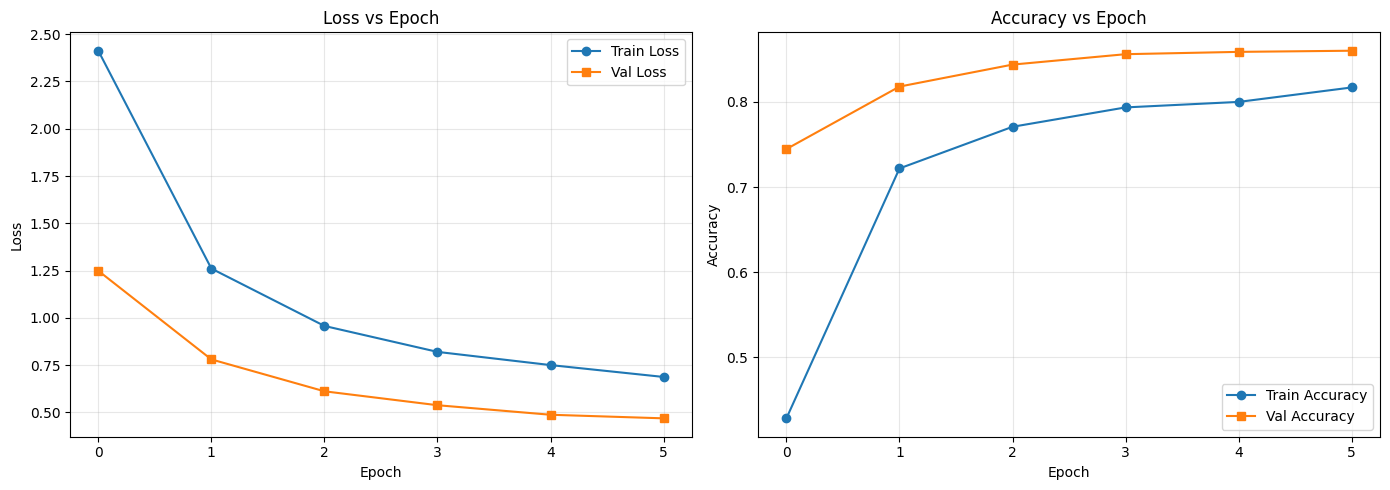

In [21]:
# 7. Evaluación final en test

plot_training_history(history)

In [22]:
# Reporte de clasificación
model.load_state_dict(torch.load("best_resnet18_oxford_pet.pth", map_location=device))
y_true, y_pred, test_loss, test_acc = evaluate(model, test_loader, criterion)

print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print("\nReporte de clasificación:")
print(classification_report(y_true, y_pred, zero_division=0))

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(



Test Loss: 0.5206
Test Accuracy: 0.8436

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.61      0.89      0.72        98
           1       0.63      0.87      0.73       100
           2       0.61      0.55      0.58       100
           3       0.87      0.92      0.89       100
           4       0.84      0.87      0.85       100
           5       0.95      0.54      0.69       100
           6       0.74      0.73      0.74       100
           7       0.97      0.80      0.88        88
           8       0.90      0.70      0.78        99
           9       1.00      0.71      0.83       100
          10       0.87      0.69      0.77       100
          11       0.62      0.96      0.76        97
          12       0.87      0.88      0.88       100
          13       0.91      0.85      0.88       100
          14       0.74      1.00      0.85       100
          15       0.91      0.99      0.95       100
          16 

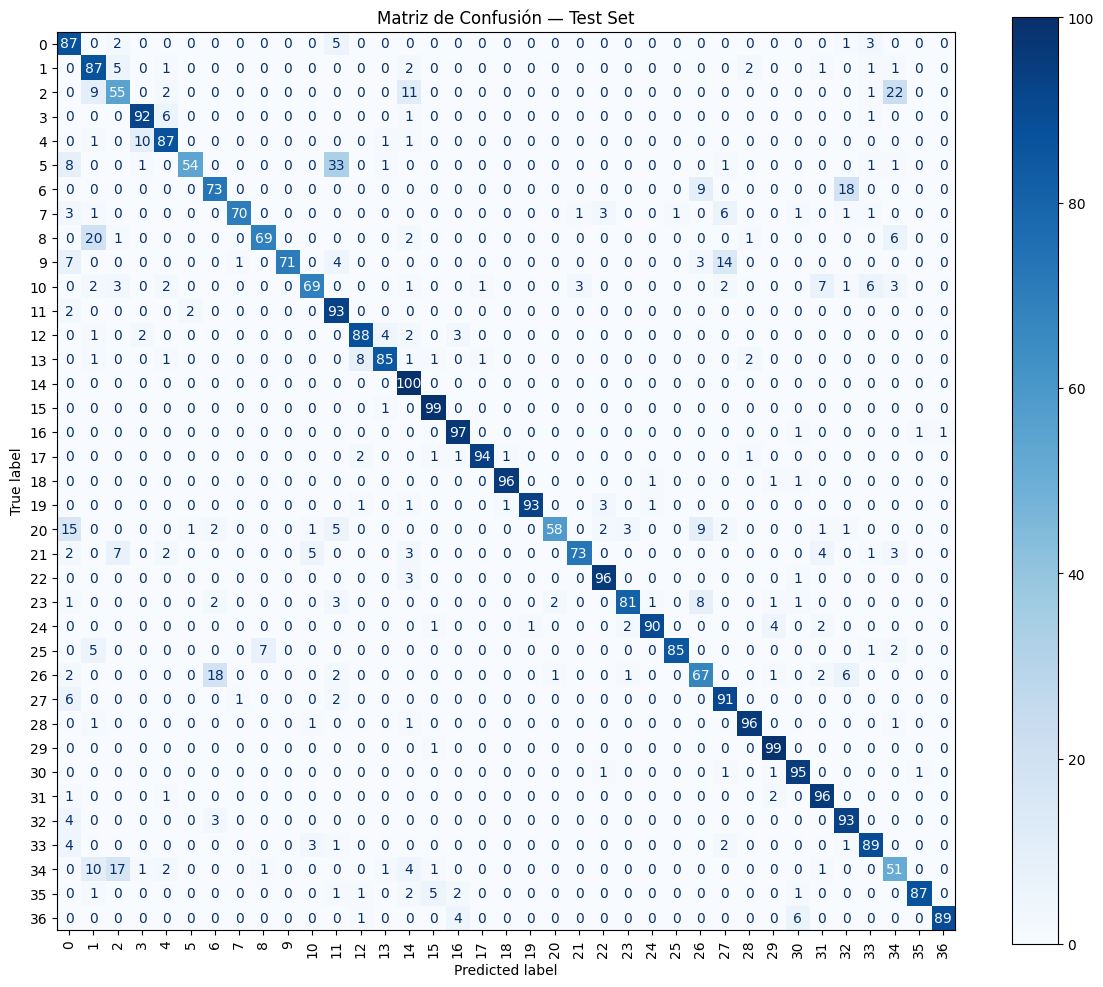

In [23]:
# Matriz de confusión
plot_confusion_matrix(y_true, y_pred, title="Matriz de Confusión — Test Set")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


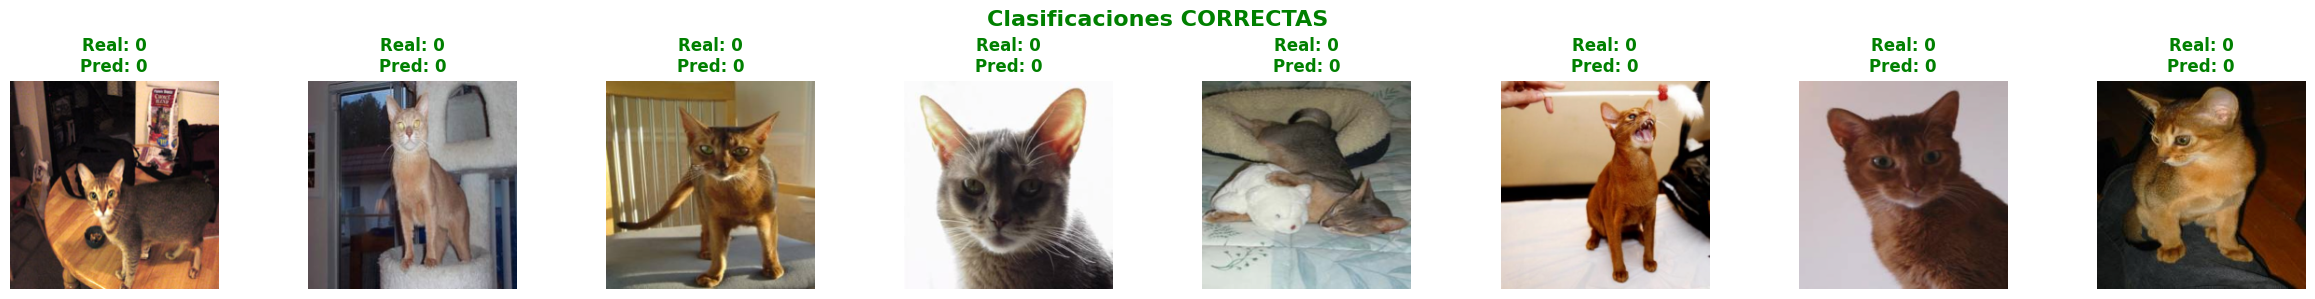

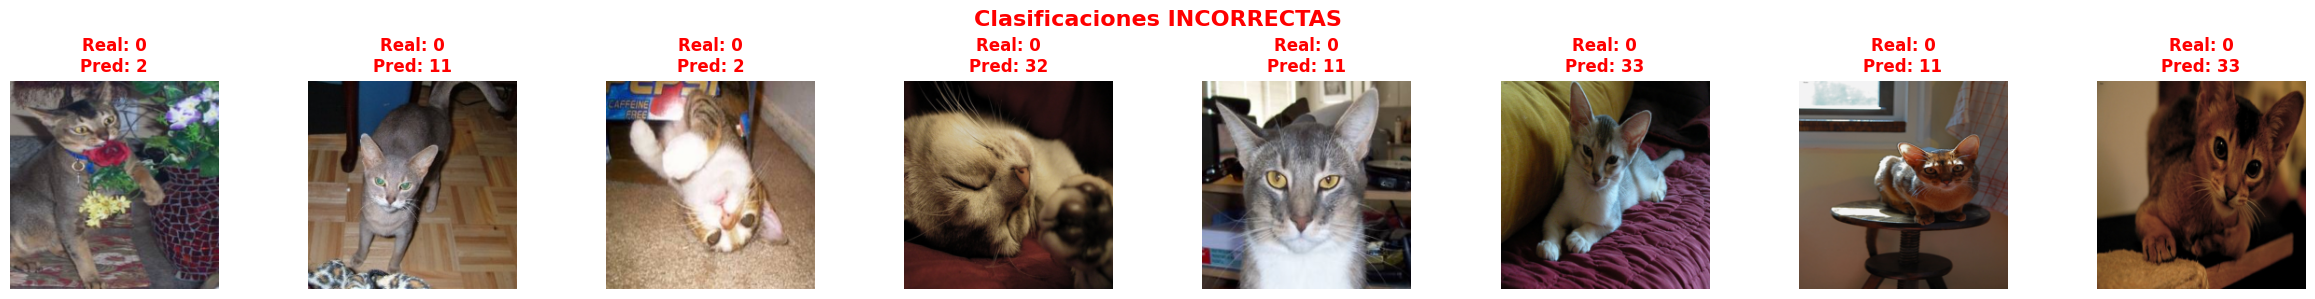

In [24]:
# Visualización de ejemplos correctos e incorrectos
plot_classification_examples(model, test_loader, n_correct=8, n_incorrect=8)